# TRABAJO FINAL MODULO 5
# ALUMNO : CÉSAR MAYTA


## MODELO DE CLASIFICACIÓN PARA TELCO CHURN

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/telco_data_transformed.csv')
df

,gender,partner,dependents,phone_service,paperless_billing,churn,device_protection_no,device_protection_noservice,device_protection_yes,movies_no,...,security_no,security_noservice,security_yes,internet_dsl,internet_fiber,internet_no,senior_citizen,tenure,monthly_charges,total_charges
0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,29.85,29.85
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,34.0,56.95,1889.50
2,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,2.0,53.85,108.15
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,45.0,42.30,1840.75
4,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,24.0,84.80,1990.50
7039,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,72.0,103.20,7362.90
7040,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,11.0,29.60,346.45
7041,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,4.0,74.40,306.60


In [ ]:
df.dropna(inplace=True)
df

,gender,partner,dependents,phone_service,paperless_billing,churn,device_protection_no,device_protection_noservice,device_protection_yes,movies_no,...,security_no,security_noservice,security_yes,internet_dsl,internet_fiber,internet_no,senior_citizen,tenure,monthly_charges,total_charges
0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,29.85,29.85
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,34.0,56.95,1889.50
2,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,2.0,53.85,108.15
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,45.0,42.30,1840.75
4,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,24.0,84.80,1990.50
7039,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,72.0,103.20,7362.90
7040,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,11.0,29.60,346.45
7041,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,4.0,74.40,306.60


In [ ]:
corr_matrix = df.corr()
corr_churn = corr_matrix[['churn']].sort_values(by='churn',ascending=False)
corr_churn

,churn
churn,1.000000
contract_month,0.404565
security_no,0.342235
tech_support_no,0.336877
internet_fiber,0.307463
payment_check,0.301455
backup_no,0.267595
device_protection_no,0.252056
monthly_charges,0.192858
paperless_billing,0.191454


In [ ]:
cols = corr_churn.index.tolist()
cols.remove('churn')
cols

['contract_month',
 'security_no',
 'tech_support_no',
 'internet_fiber',
 'payment_check',
 'backup_no',
 'device_protection_no',
 'monthly_charges',
 'paperless_billing',
 'senior_citizen',
 'movies_no',
 'tv_no',
 'tv_yes',
 'movies_yes',
 'multiple_lines_yes',
 'phone_service',
 'gender',
 'multiple_lines_noservice',
 'multiple_lines_no',
 'device_protection_yes',
 'backup_yes',
 'payment_mail',
 'payment_transfer',
 'internet_dsl',
 'payment_creditcard',
 'partner',
 'dependents',
 'tech_support_yes',
 'security_yes',
 'contract_year',
 'total_charges',
 'device_protection_noservice',
 'security_noservice',
 'tech_support_noservice',
 'movies_noservice',
 'tv__no internet service',
 'internet_no',
 'backup_noservice',
 'contract_twoyears',
 'tenure']

In [ ]:
X = df[cols].values
y = df['churn'].values.reshape(-1,1)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

# CREAMOS UN CODIGO PARA PODER EVALUAR VARIOS MODELOS

## 1 - IMPORTAMOS LIBRERIAS

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

## 2 - DEFINIMOS LOS MODELOS A EVALUAR

In [ ]:
modelos_clasificacion = {
    "Regresión Logística": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "k-Nearest Neighbors": KNeighborsClassifier(n_neighbors=2),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    "SVM (RBF)": SVC(kernel='rbf')
}

## 3 - CREAMOS FUNCIÓN DE EVALUACIÓN

In [ ]:
def evaluar_clasificador(modelo, nombre):
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f'\n{nombre}:')
    print(f'Accuracy: {accuracy:.4f}')
    #print(classification_report(y_test, y_pred))
    return accuracy

## 4 - ENTRENAMOS Y COMPARAMOS MODELOS

In [ ]:
resultados_clasificacion = {}
for nombre, modelo in modelos_clasificacion.items():
    resultados_clasificacion[nombre] = evaluar_clasificador(modelo, nombre)

# Mostrar el mejor modelo
mejor_modelo_clasificacion = max(resultados_clasificacion, key=resultados_clasificacion.get)
print(f'\nEl mejor modelo es: {mejor_modelo_clasificacion} con un Accuracy de {resultados_clasificacion[mejor_modelo_clasificacion]:.4f}')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



Regresión Logística:
Accuracy: 0.7868

Random Forest:
Accuracy: 0.7839

k-Nearest Neighbors:
Accuracy: 0.7548


/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



Gradient Boosting:
Accuracy: 0.7889


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



SVM (RBF):
Accuracy: 0.7811

El mejor modelo es: Gradient Boosting con un Accuracy de 0.7889


## 5. GRAFICAMOS RESULTADOS

/tmp/ipykernel_1227/219317408.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(resultados_clasificacion.keys()), y=list(resultados_clasificacion.values()), palette='mako')


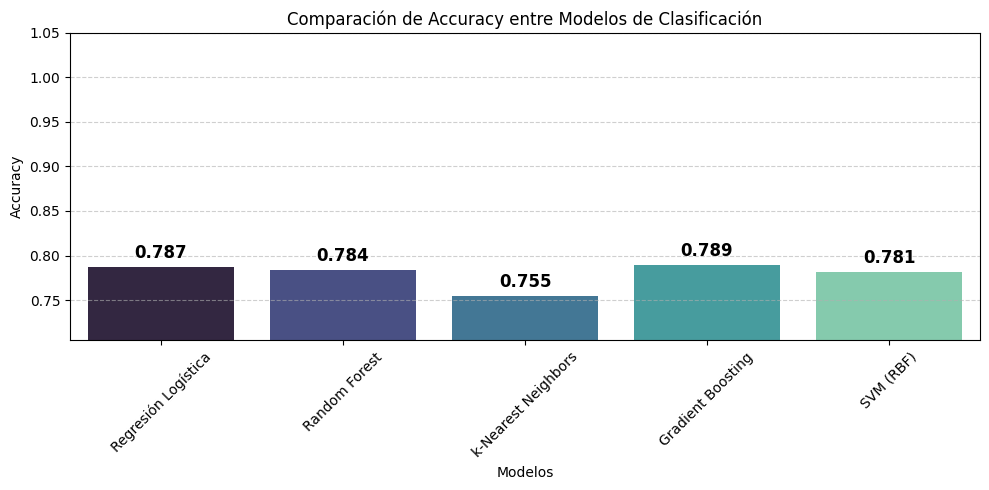

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Comparación del Accuracy entre modelos de clasificación
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=list(resultados_clasificacion.keys()), y=list(resultados_clasificacion.values()), palette='mako')

# Agregar etiquetas en cada barra
for index, value in enumerate(resultados_clasificacion.values()):
    ax.text(index, value + 0.01, f'{value:.3f}', ha='center', fontsize=12, fontweight='bold')

plt.ylim(min(resultados_clasificacion.values()) - 0.05, 1.05)
plt.xlabel('Modelos')
plt.ylabel('Accuracy')
plt.title('Comparación de Accuracy entre Modelos de Clasificación')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## CREAMOS UNA MATRIZ DE CONFUSIÓN

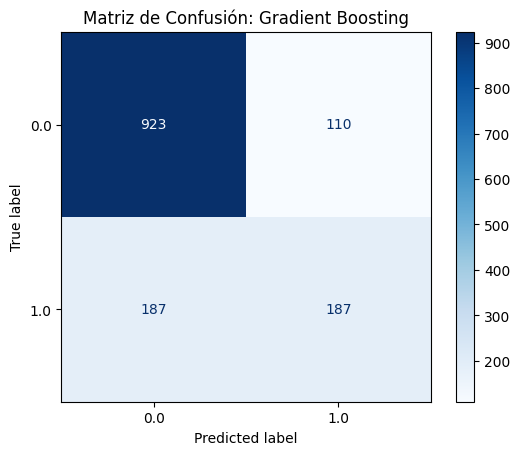

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Evaluación del mejor modelo de clasificación
modelo_clasificacion_seleccionado = modelos_clasificacion[mejor_modelo_clasificacion]
y_pred_clasificacion = modelo_clasificacion_seleccionado.predict(X_test)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_clasificacion)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo_clasificacion_seleccionado.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Matriz de Confusión: {mejor_modelo_clasificacion}')
plt.show()